In [1]:
from evolution import time_evolve, animate
from scipy.special import gamma
import numpy as np
import matplotlib.pyplot as plt

In [2]:
lam = 10
x0, p0 = 0., np.sqrt(lam-0.25)
breadth = 10

unbound_energy = lam ** 2 - 1
x_unbound = np.arccosh(1/np.sqrt((unbound_energy - lam**2) / (-lam * (lam+1))))
width = breadth - x_unbound

domain = np.linspace(-breadth, breadth, 1000, dtype=np.complex128)
dx = np.abs(domain[1] - domain[0])

Vx = -lam * (lam + 1) / np.cosh(domain) ** 2 + lam**2

c = np.sqrt(gamma(lam+0.5)/(np.sqrt(np.pi) * gamma(lam)))
psi_0 = c * (1 / np.cosh(domain - x0) ** lam)
psi_0 *= np.exp(1j * p0 * domain)

In [3]:
def cap(domain, width=1.0, strength=10.0, order=2):
    V_cap = np.zeros_like(domain, dtype=np.complex128)
    x_min, x_max = domain[0], domain[-1]

    mask_left = domain < (x_min + width)
    V_cap[mask_left] = -1j * strength * ((x_min + width - domain[mask_left])/width)**order

    mask_right = domain > (x_max - width)
    V_cap[mask_right] = -1j * strength * ((domain[mask_right] - (x_max - width))/width)**order

    return V_cap
V_cap = cap(domain, width=width, strength=10.0, order=2)
Vx = Vx + V_cap

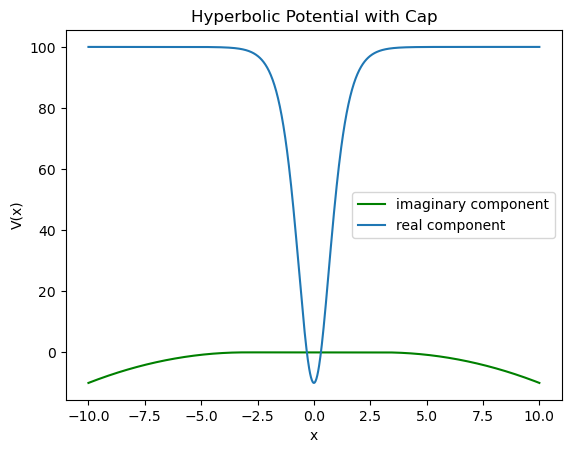

In [4]:
plt.plot(domain.real, Vx.imag, label='imaginary component', c='g')
plt.plot(domain.real, Vx.real, label='real component')
plt.title('Hyperbolic Potential with Cap')
plt.legend()
plt.ylabel('V(x)')
plt.xlabel('x')
plt.show()

In [5]:
max_t = 10
dt = dx ** 2
# dt = 1e-3
T = int(max_t / dt) + 1
results = time_evolve(domain, psi_0, Vx, max_t, it=T)

100%|██████████| 24952/24952 [00:04<00:00, 5571.76it/s]


In [6]:
t_eval = np.array(results['t'])
E_q = np.array(results['T']) + np.array(results['V'])

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


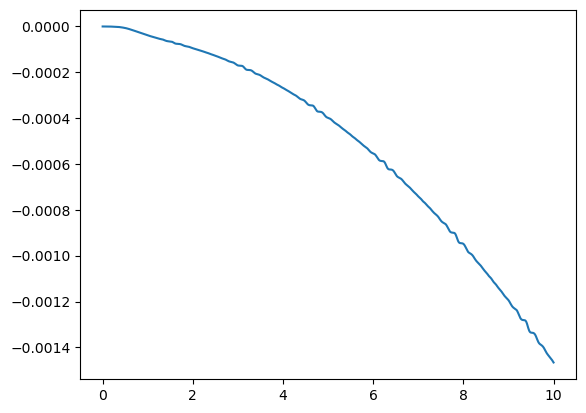

In [7]:
plt.plot(t_eval, results['err_norm'])

In [8]:
from scipy.integrate import solve_ivp

def hamilton_eqs(_, y):
    x, p = y
    dxdt = 2 * p
    dpdt = -2 * lam**2 * np.tanh(x) * (1 - np.tanh(x)**2) 
    return [dxdt, dpdt]

sol = solve_ivp(
    hamilton_eqs,
    t_span=(0, max_t),
    y0=[x0, p0],
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12
)

x_classical = sol.y[0]
p_classical = sol.y[1]

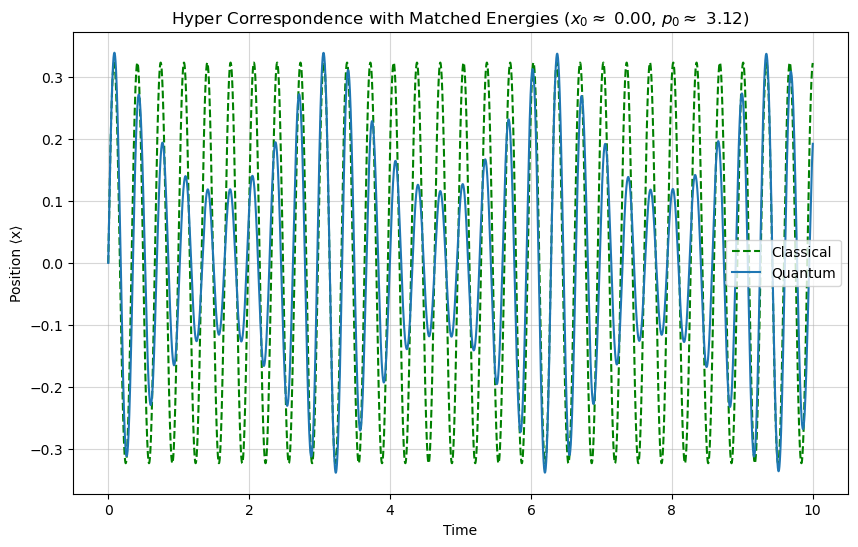

In [9]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t_eval, x_classical, '--', c='g', label='Classical')
plt.plot(t_eval, results['x'], label='Quantum')
plt.title(f'Hyper Correspondence with Matched Energies ($x_0\\approx$ {x0:.2f}, $p_0 \\approx$ {p0:.2f})')
plt.ylabel("Position ⟨x⟩")
plt.xlabel("Time")
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

In [10]:
probs = np.abs(results['psi_avg']) ** 2
# animate(domain.real, probs[::50], max_t)